# RL 13 - Exploration par curiosité : Random Network Distillation (RND)

Dans la plupart des notebooks précédents, l'exploration reposait sur l'aléa : tirage
**epsilon-greedy** (notebooks 1, 3, 6), bandits (notebook 4) ou bonus de comptage **Dyna-Q+**
(notebook 8). Ces stratégies suffisent quand les récompenses sont fréquentes, mais elles
**échouent dès que la récompense est rare** : l'agent peut errer des milliers de pas sans
jamais rencontrer le moindre signal qui oriente son apprentissage.

Ce notebook présente la **motivation intrinsèque** (curiosité) et, en particulier, l'algorithme
**Random Network Distillation** (RND, Burda et al., 2018), qui a permis les premiers progrès
marquants sur des environnements à exploration difficile comme *Montezuma's Revenge*.

## Objectifs pédagogiques

- Comprendre pourquoi l'exploration aléatoire échoue dans les environnements à **récompense parcimonieuse**.
- Définir une **récompense intrinsèque** mesurant la **nouveauté** d'un état.
- Implémenter RND : une **cible aléatoire figée** et un **prédicteur entraîné**, dont l'erreur de
  prédiction sert de bonus de curiosité.
- Visualiser le mécanisme comme un **détecteur de nouveauté** (Partie A) puis observer son effet
  sur un **piège d'exploitation** (Partie B), où epsilon-greedy reste bloqué et RND s'en échappe.

> Prérequis : notebooks 3 (DQN / experience replay), 4 (bandits) et 8 (Dyna-Q+, bonus d'exploration).

## 1. Le problème de l'exploration profonde

On distingue **exploration superficielle** et **exploration profonde** :

- **Superficielle** : il suffit de quelques actions aléatoires pour découvrir une meilleure
  récompense locale. Epsilon-greedy y suffit.
- **Profonde** : la récompense intéressante n'est atteignable qu'après une **longue séquence
  cohérente** d'actions. Une marche aléatoire a une probabilité **exponentiellement faible** de
  l'atteindre, et l'agent se contente alors d'un optimum local.

Le **piège d'exploitation** est le cas canonique : une petite récompense facile à atteindre
« capture » la politique, qui n'explore jamais assez loin pour trouver la grande récompense.
C'est exactement la situation que nous reproduirons en Partie B.

### L'idée de la motivation intrinsèque

Plutôt que de ne maximiser que la récompense de l'environnement (**extrinsèque**), on ajoute une
**récompense intrinsèque** $r^i_t$ qui récompense la **nouveauté** :

$$ r_t = r^e_t + \beta\, r^i_t $$

où $\beta > 0$ pondère la curiosité. L'agent est alors poussé vers les états **rarement visités**,
ce qui le mène à explorer systématiquement l'espace d'états — y compris les régions lointaines où
se cache la grande récompense.

Le défi est de **mesurer la nouveauté** sans table de comptage (impraticable en grand espace
d'états continu). RND apporte une réponse élégante.

## 2. Le mécanisme RND

RND repose sur **deux réseaux** prenant l'état $s$ en entrée :

1. Une **cible** $f$ : un réseau aux **poids aléatoires figés** (jamais entraîné). Elle définit une
   fonction fixe mais arbitraire $f(s)$.
2. Un **prédicteur** $\hat f_\theta$ : un réseau entraîné à **imiter la cible** sur les états
   effectivement visités, en minimisant $\lVert \hat f_\theta(s) - f(s) \rVert^2$.

La **récompense intrinsèque** est l'erreur de prédiction :

$$ r^i(s) = \lVert \hat f_\theta(s) - f(s) \rVert^2 $$

**Pourquoi cela fonctionne ?**

- Sur un état **souvent visité**, le prédicteur a eu de nombreuses occasions d'apprendre : l'erreur
  est **faible** → peu de bonus.
- Sur un état **nouveau**, le prédicteur n'a jamais vu cette entrée : l'erreur est **élevée** →
  fort bonus.

L'erreur de prédiction agit donc comme un **pseudo-comptage** de visites : c'est une mesure de
nouveauté qui **se généralise** naturellement aux grands espaces d'états (contrairement à un
comptage tabulaire). On commence par illustrer ce mécanisme isolément.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import random

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.set_num_threads(2)
print("Environnement prêt - torch", torch.__version__)

Environnement prêt - torch 2.11.0+cpu


In [2]:
class RNDNet(nn.Module):
    """Petit MLP utilisé à la fois pour la cible (figée) et le prédicteur (entraîné)."""
    def __init__(self, in_dim, out_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, out_dim),
        )
    def forward(self, x):
        return self.net(x)

def make_rnd(in_dim, out_dim=8, hidden=64, lr=1e-3):
    """Crée le couple (cible figée, prédicteur entraînable) et l'optimiseur du prédicteur."""
    target = RNDNet(in_dim, out_dim, hidden)
    for p in target.parameters():
        p.requires_grad_(False)            # cible aléatoire : jamais entraînée
    predictor = RNDNet(in_dim, out_dim, hidden)
    opt = torch.optim.Adam(predictor.parameters(), lr=lr)
    return target, predictor, opt

def novelty(target, predictor, x):
    """Erreur de prédiction = signal de nouveauté (bonus intrinsèque)."""
    return ((predictor(x) - target(x)) ** 2).sum(-1)

## Partie A - RND comme détecteur de nouveauté (jouet 2D)

Avant de l'intégrer à un agent, isolons le mécanisme. On définit une **région « visitée »** :
un nuage de points 2D centré autour de $(-0.5, -0.5)$. On entraîne le prédicteur **uniquement sur
cette région**, puis on mesure la nouveauté dans la région visitée et dans une région **inconnue**
centrée en $(0.6, 0.6)$.

Attendu : l'erreur de prédiction doit être **quasi nulle** sur la région apprise et **nettement
plus élevée** sur la région jamais vue.

In [3]:
# Région "visitée" : un nuage de points autour de (-0.5, -0.5)
torch.manual_seed(SEED); np.random.seed(SEED)
target, predictor, opt = make_rnd(in_dim=2, out_dim=8)
visited = torch.tensor(np.random.randn(2000, 2) * 0.15 + np.array([-0.5, -0.5]),
                       dtype=torch.float32)

errs = []
for step in range(300):
    idx = torch.randint(0, visited.size(0), (128,))
    loss = novelty(target, predictor, visited[idx]).mean()
    opt.zero_grad(); loss.backward(); opt.step()
    errs.append(loss.item())

with torch.no_grad():
    near = novelty(target, predictor, visited[:500]).mean().item()
    far_pts = torch.tensor(np.random.randn(500, 2) * 0.15 + np.array([0.6, 0.6]),
                           dtype=torch.float32)
    far = novelty(target, predictor, far_pts).mean().item()

print(f"Nouveauté region visitee  : {near:.5f}")
print(f"Nouveauté region inconnue : {far:.5f}")
print(f"Ratio inconnue / visitee  : {far / max(near, 1e-9):.0f}x")

Nouveauté region visitee  : 0.00003
Nouveauté region inconnue : 0.06064
Ratio inconnue / visitee  : 1969x


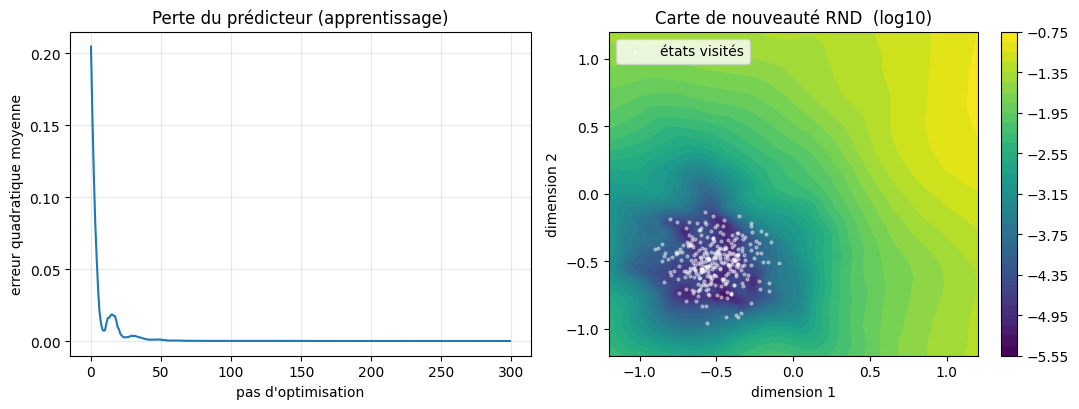

In [4]:
# Carte de nouveauté sur une grille 2D + courbe d'apprentissage du prédicteur
xs = np.linspace(-1.2, 1.2, 80); ys = np.linspace(-1.2, 1.2, 80)
gx, gy = np.meshgrid(xs, ys)
grid = torch.tensor(np.stack([gx.ravel(), gy.ravel()], 1), dtype=torch.float32)
with torch.no_grad():
    heat = novelty(target, predictor, grid).numpy().reshape(gx.shape)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].plot(errs)
ax[0].set_title("Perte du prédicteur (apprentissage)")
ax[0].set_xlabel("pas d'optimisation"); ax[0].set_ylabel("erreur quadratique moyenne")
ax[0].grid(alpha=0.3)
im = ax[1].contourf(gx, gy, np.log10(heat + 1e-8), levels=30, cmap="viridis")
ax[1].scatter(visited[:300, 0], visited[:300, 1], s=4, c="white", alpha=0.4,
              label="états visités")
ax[1].set_title("Carte de nouveauté RND  (log10)")
ax[1].set_xlabel("dimension 1"); ax[1].set_ylabel("dimension 2")
ax[1].legend(loc="upper left")
fig.colorbar(im, ax=ax[1])
plt.tight_layout(); plt.show()

**Interprétation.** Le ratio nouveauté inconnue / visitée est de l'ordre de **plusieurs centaines
à plusieurs milliers** : le prédicteur reproduit fidèlement la cible là où il a été entraîné
(erreur quasi nulle, zone sombre de la carte autour du nuage blanc) et **échoue** partout ailleurs
(erreur élevée, zones claires). La carte de nouveauté est donc une **mesure d'inexploration** :
c'est exactement le signal qu'un agent doit suivre pour aller voir ce qu'il n'a pas encore vu.

À mesure que l'agent visiterait de nouvelles régions, le prédicteur les apprendrait à son tour et
leur bonus **diminuerait** — la curiosité est **auto-extinctive**, ce qui évite que l'agent reste
fasciné indéfiniment par la même zone.

## Partie B - Le piège d'exploitation (MDP en chaîne)

On construit un MDP en **chaîne** de $N$ états (ici $N=16$) :

- L'agent démarre à l'état $0$. Deux actions : **gauche** (0) ou **droite** (1).
- **Gauche depuis l'état 0** mène immédiatement à une **petite récompense** $r=0.1$ (le piège), et
  l'épisode se termine.
- Aller **à droite** de façon répétée jusqu'à l'état $N-1$ donne la **grande récompense** $r=1.0$.

C'est un cas d'**exploration profonde** : atteindre la grande récompense exige $N-1$ actions
« droite » consécutives. Une politique gloutonne découvre le petit gain en **une seule action** et
s'y enferme. Seule une exploration dirigée vers la frontière inexplorée permet d'atteindre le grand
gain. On compare **epsilon-greedy pur** et **Q-learning + bonus RND** (la nouveauté est calculée
sur l'encodage one-hot de l'état, ce qui en fait un pseudo-comptage neuronal).

In [5]:
SMALL, BIG = 0.1, 1.0

def make_chain(N):
    """MDP en chaîne. Gauche depuis l'état 0 -> petit piège ; droite jusqu'à N-1 -> grand gain."""
    def step(s, a):
        if s == 0 and a == 0:                 # gauche au départ : piège terminal
            return 0, SMALL, True
        ns = min(N - 1, s + 1) if a == 1 else max(0, s - 1)
        if ns == N - 1:                       # frontière droite : grande récompense
            return ns, BIG, True
        return ns, 0.0, False
    return step

def onehot(s, N):
    v = torch.zeros(1, N); v[0, s] = 1.0
    return v

def train_chain(use_rnd, N=16, episodes=500, beta=0.8, pred_lr=3e-4, seed=SEED):
    """Q-learning tabulaire sur la chaîne, avec bonus RND optionnel.
    Retourne (récompenses extrinsèques par épisode, histogramme de visites d'états)."""
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    step_env = make_chain(N)
    Q = np.zeros((N, 2)); alpha, GAMMA, H = 0.5, 0.99, 3 * N
    target, predictor, opt = make_rnd(in_dim=N, out_dim=8, lr=pred_lr)
    returns, visits = [], np.zeros(N)
    for ep in range(episodes):
        s = 0; ext_ret = 0.0
        eps = max(0.05, 1.0 - ep / (episodes * 0.5))          # décroissance d'epsilon
        for _ in range(H):
            a = random.randint(0, 1) if random.random() < eps else int(np.argmax(Q[s]))
            ns, ext, done = step_env(s, a)
            visits[ns] += 1
            r = ext
            if use_rnd:
                with torch.no_grad():
                    nov = novelty(target, predictor, onehot(ns, N)).item()
                r = ext + beta * nov                          # récompense augmentée
                loss = novelty(target, predictor, onehot(ns, N)).mean()
                opt.zero_grad(); loss.backward(); opt.step()  # le prédicteur apprend l'état visité
            Q[s, a] += alpha * (r + GAMMA * (0.0 if done else Q[ns].max()) - Q[s, a])
            s = ns; ext_ret += ext
            if done:
                break
        returns.append(ext_ret)
    return np.array(returns), visits

In [6]:
N = 16
ret_eps, vis_eps = train_chain(use_rnd=False, N=N)
ret_rnd, vis_rnd = train_chain(use_rnd=True,  N=N)

def smooth(x, k=20):
    return np.convolve(x, np.ones(k) / k, mode="valid")

print(f"epsilon-greedy : récompense moyenne (50 derniers ép.) = {ret_eps[-50:].mean():.3f}")
print(f"RND (curiosité): récompense moyenne (50 derniers ép.) = {ret_rnd[-50:].mean():.3f}")
print(f"RND atteint la grande récompense dans "
      f"{100 * np.mean(ret_rnd[-50:] >= 0.9 * BIG):.0f}% des 50 derniers épisodes")

epsilon-greedy : récompense moyenne (50 derniers ép.) = 0.100
RND (curiosité): récompense moyenne (50 derniers ép.) = 0.964
RND atteint la grande récompense dans 96% des 50 derniers épisodes


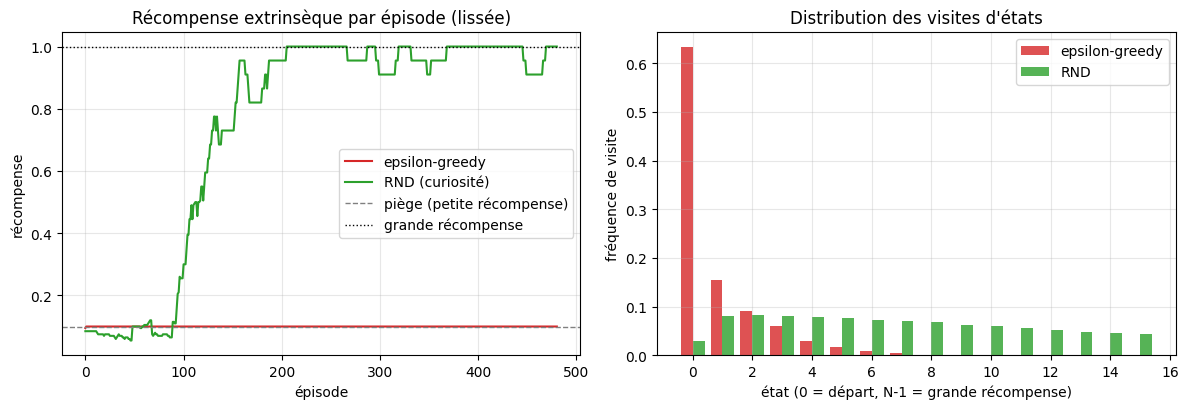

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot(smooth(ret_eps), label="epsilon-greedy", color="tab:red")
ax[0].plot(smooth(ret_rnd), label="RND (curiosité)", color="tab:green")
ax[0].axhline(SMALL, ls="--", c="gray", lw=1, label="piège (petite récompense)")
ax[0].axhline(BIG, ls=":", c="black", lw=1, label="grande récompense")
ax[0].set_title("Récompense extrinsèque par épisode (lissée)")
ax[0].set_xlabel("épisode"); ax[0].set_ylabel("récompense"); ax[0].legend(); ax[0].grid(alpha=0.3)

w = 0.4; idx = np.arange(N)
ax[1].bar(idx - w / 2, vis_eps / vis_eps.sum(), w, label="epsilon-greedy",
          color="tab:red", alpha=0.8)
ax[1].bar(idx + w / 2, vis_rnd / vis_rnd.sum(), w, label="RND", color="tab:green", alpha=0.8)
ax[1].set_title("Distribution des visites d'états")
ax[1].set_xlabel("état (0 = départ, N-1 = grande récompense)")
ax[1].set_ylabel("fréquence de visite")
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Interprétation.** La courbe rouge (epsilon-greedy) **plafonne sur la petite récompense** (~0.1) :
dès qu'elle a découvert le piège à gauche, la politique s'y enferme. La courbe verte (RND)
**décolle** et converge vers la **grande récompense** (~1.0) dans la quasi-totalité des derniers
épisodes.

L'histogramme de visites raconte la même histoire : epsilon-greedy concentre ses visites sur les
**premiers états** (près du départ et du piège), tandis que RND **répartit ses visites jusqu'à la
frontière droite** $N-1$. Le bonus de nouveauté a transformé une exploration myope en une
**exploration profonde et dirigée**, qui seule permet de sortir du piège d'exploitation.

## 3. RND par rapport aux autres approches d'exploration

| Approche | Mesure de nouveauté | Passage à l'échelle | Notebook |
|----------|---------------------|---------------------|----------|
| Epsilon-greedy | aucune (aléa uniforme) | trivial mais myope | 1, 3, 6 |
| Comptage tabulaire / Dyna-Q+ | $1/\sqrt{N(s)}$ | limité aux petits espaces | 8 |
| Pseudo-comptage (modèles de densité) | densité estimée | moyen, coûteux | - |
| **RND** | **erreur de prédiction d'une cible figée** | **excellent** (réseau) | **13 (ici)** |
| ICM (Curiosity, Pathak 2017) | erreur d'un modèle de dynamique inverse/avant | excellent | - |

Le grand mérite de RND est sa **simplicité** : pas de modèle de dynamique, pas d'estimation de
densité, juste **deux petits réseaux** et une erreur quadratique. C'est ce qui en a fait une
référence pour l'exploration dans les environnements à récompense rare.

### Limites et bonnes pratiques

- **Normalisation** : en pratique, on normalise les observations *et* la récompense intrinsèque
  (par un écart-type courant) pour stabiliser l'échelle du bonus — c'est l'objet de l'exercice 2.
- **Distraction télévisuelle** (*noisy-TV problem*) : si l'environnement contient de l'aléa
  irréductible (un écran de bruit), RND y voit une nouveauté permanente et peut s'y bloquer.
- **Décroissance du bonus** : le bonus s'éteint à mesure que le prédicteur apprend ; il faut donc
  que l'apprentissage de la valeur soit assez rapide pour exploiter la grande récompense une fois
  découverte. En pratique, le **taux d'apprentissage du prédicteur** est un réglage sensible : trop
  élevé, le prédicteur apprend la frontière inexplorée plus vite que l'agent ne l'exploite et le
  bonus s'évanouit avant d'avoir servi (l'agent retombe dans le piège) ; on le choisit donc
  **plus lent** que celui de la fonction de valeur.

## 4. Exercices

Les trois exercices ci-dessous réutilisent les fonctions définies plus haut (`train_chain`,
`make_chain`, `make_rnd`, `novelty`). Chaque squelette est à compléter ; le notebook s'exécute de
bout en bout même si les exercices ne sont pas encore traités.

### Exercice 1 - Effet du coefficient de curiosité $\beta$

**Objectif.** Étudier le compromis exploration / exploitation en fonction de $\beta$.
Un $\beta$ trop faible laisse l'agent tomber dans le piège ; un $\beta$ trop fort peut rendre
l'exploration erratique et ralentir l'exploitation une fois la grande récompense trouvée.

**Indices.**
- Réutiliser `train_chain(use_rnd=True, beta=...)` pour chaque valeur de $\beta$.
- Relever la récompense finale moyenne `ret[-50:].mean()`.
- Tracer récompense finale en fonction de $\beta$.

In [8]:
def explore_beta(betas=(0.0, 0.1, 0.8, 3.0)):
    """EXERCICE 1 - Pour chaque beta, entraîner l'agent RND et relever la récompense finale.
    Retourner un dictionnaire {beta: récompense_finale_moyenne}.
    """
    # TODO etudiant : completer
    results = None  # exemple attendu : {b: train_chain(use_rnd=True, beta=b)[0][-50:].mean() for b in betas}
    return results

# resultats = explore_beta()
# print(resultats)

### Exercice 2 - Normalisation de la récompense intrinsèque

**Objectif.** Reproduire une pratique clé de Burda et al. (2018) : diviser le bonus intrinsèque par
un **écart-type courant** des erreurs de prédiction, afin que l'échelle du bonus reste stable au
fil de l'entraînement (les erreurs sont grandes au début, petites ensuite).

**Indices.**
- Maintenir une moyenne / variance incrémentale (algorithme de Welford) des erreurs intrinsèques.
- Remplacer `r = ext + beta * nov` par `r = ext + beta * nov / (std_courant + 1e-8)`.
- Comparer la stabilité de la courbe d'apprentissage à celle de `train_chain`.

In [9]:
class RunningStd:
    """À compléter : moyenne/écart-type courants (Welford) des erreurs intrinsèques."""
    def __init__(self):
        # TODO etudiant : initialiser n, mean, M2
        pass
    def update(self, x):
        # TODO etudiant : mise à jour incrémentale
        pass
    @property
    def std(self):
        # TODO etudiant : renvoyer l'écart-type courant
        return None

def train_chain_normalized(N=16, episodes=500, beta=0.8, pred_lr=3e-4, seed=SEED):
    """EXERCICE 2 - Variante de train_chain avec normalisation du bonus intrinsèque.
    S'inspirer de train_chain et utiliser RunningStd pour diviser `nov` par l'écart-type courant.
    """
    # TODO etudiant : completer en s'inspirant de train_chain
    pass

# ret_norm, _ = train_chain_normalized()

### Exercice 3 - Jusqu'où la curiosité tient-elle ?

**Objectif.** Caractériser le régime où l'exploration profonde par RND reste efficace.
Allonger la chaîne (augmenter $N$) et / ou ajouter un **second piège**, puis déterminer le taux de
succès de RND pour atteindre la grande récompense.

**Indices.**
- Balayer $N \in \{16, 20, 24, 32\}$ et relever, pour chaque $N$, la fraction d'épisodes finaux où
  la grande récompense est atteinte.
- Optionnel : modifier `make_chain` pour insérer un second distracteur en milieu de chaîne.
- Discuter : à partir de quelle longueur la curiosité ne suffit-elle plus dans ce budget d'épisodes ?

In [10]:
def success_vs_length(Ns=(16, 20, 24, 32), episodes=500):
    """EXERCICE 3 - Taux de succès de RND en fonction de la longueur de chaîne N.
    Retourner {N: fraction des 50 derniers épisodes atteignant la grande récompense}.
    """
    # TODO etudiant : completer
    return None

# taux = success_vs_length()
# print(taux)

## 5. Synthèse

- L'**exploration aléatoire** (epsilon-greedy) échoue dès que la récompense est rare ou cachée
  derrière une longue séquence d'actions : elle reste piégée dans les optima locaux faciles.
- La **motivation intrinsèque** ajoute un bonus de **nouveauté** qui pousse l'agent vers les états
  inexplorés, transformant l'exploration myope en **exploration profonde**.
- **RND** mesure la nouveauté par l'**erreur de prédiction d'une cible aléatoire figée** : simple,
  sans modèle de dynamique, et capable de passer à l'échelle des grands espaces d'états.
- Sur le piège d'exploitation, RND s'échappe vers la grande récompense (~1.0) là où epsilon-greedy
  plafonne sur le piège (~0.1) — un écart **net et reproductible**.

### Pour aller plus loin

- **ICM** (Pathak et al., 2017) : curiosité fondée sur un modèle de dynamique avant/inverse.
- **Go-Explore** (Ecoffet et al., 2019) : mémoriser et revisiter les états prometteurs.
- Combiner RND avec un agent **DQN** (notebook 3) ou **PPO** (notebook 6c) sur un environnement
  continu à récompense parcimonieuse (ex. *MountainCar*, *Montezuma's Revenge*).

### Références

- Burda, Edwards, Storkey, Klimov (2018). *Exploration by Random Network Distillation*. ICLR 2019.
- Pathak, Agrawal, Efros, Darrell (2017). *Curiosity-driven Exploration by Self-supervised Prediction*. ICML.
- Osband et al. (2019). *Deep Exploration via Randomized Value Functions*. JMLR.